In [1]:
!pip install openpyxl
!pip install statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings

warnings.filterwarnings("ignore")

In [11]:
# Loading the data

cpi_ireland = pd.read_excel(r"C:\Users\ROHITASH\Downloads\CPI Ireland.xlsx")
cpi_usa = pd.read_excel(r"C:\Users\ROHITASH\Downloads\CPI_USA.xlsx")
exchange_rate = pd.read_excel(r"C:\Users\ROHITASH\Downloads\DEXUSEU.xlsx")

In [13]:
# Preview the data

cpi_ireland.head(), cpi_usa.head(), exchange_rate.head()

(        DATE      CPI_IE
 0 2014-03-01  101.337449
 1 2014-04-01  101.234568
 2 2014-05-01  101.131687
 3 2014-06-01  101.234568
 4 2014-07-01  101.234568,
         DATE  CPI_USA
 0 2014-03-01  236.028
 1 2014-04-01  236.468
 2 2014-05-01  236.918
 3 2014-06-01  237.231
 4 2014-07-01  237.498,
         DATE   DEXUSEU
 0 2014-03-01  1.382819
 1 2014-04-01  1.381018
 2 2014-05-01  1.373350
 3 2014-06-01  1.359486
 4 2014-07-01  1.353670)

In [15]:
# Renaming columns for consistency
cpi_ireland.rename(columns={'CPI_IE': 'CPI_Ireland'}, inplace=True)
cpi_usa.rename(columns={'CPI_USA': 'CPI_USA'}, inplace=True)
exchange_rate.rename(columns={'DEXUSEU': 'Nominal_Exchange_Rate'}, inplace=True)

In [17]:
# Converting DATE column to datetime format

cpi_ireland['DATE'] = pd.to_datetime(cpi_ireland['DATE'])
cpi_usa['DATE'] = pd.to_datetime(cpi_usa['DATE'])
exchange_rate['DATE'] = pd.to_datetime(exchange_rate['DATE'])

In [19]:
# Merging datasets on DATE
combined_df = pd.merge(cpi_ireland, cpi_usa, on='DATE', how='inner')
combined_df = pd.merge(combined_df, exchange_rate, on='DATE', how='inner')

In [21]:
print(combined_df)

          DATE  CPI_Ireland  CPI_USA  Nominal_Exchange_Rate
0   2014-03-01   101.337449  236.028               1.382819
1   2014-04-01   101.234568  236.468               1.381018
2   2014-05-01   101.131687  236.918               1.373350
3   2014-06-01   101.234568  237.231               1.359486
4   2014-07-01   101.234568  237.498               1.353670
..         ...          ...      ...                    ...
116 2023-11-01   119.032922  308.087               1.081668
117 2023-12-01   119.547325  308.735               1.091410
118 2024-01-01   119.032922  309.794               1.090861
119 2024-02-01   119.547325  311.022               1.079186
120 2024-03-01   119.753086  312.107               1.083200

[121 rows x 4 columns]


In [23]:
# Rebasing CPI data to 2015 = 100

# Getting the average CPI values for the year 2015
base_cpi_ireland = combined_df[(combined_df['DATE'].dt.year == 2015)]['CPI_Ireland'].mean()
base_cpi_usa = combined_df[(combined_df['DATE'].dt.year == 2015)]['CPI_USA'].mean()

In [25]:
# Rebase both CPI series
combined_df['CPI_Ireland_2015_Base'] = (combined_df['CPI_Ireland'] / base_cpi_ireland) * 100
combined_df['CPI_USA_2015_Base'] = (combined_df['CPI_USA'] / base_cpi_usa) * 100

combined_df[['DATE', 'CPI_Ireland_2015_Base', 'CPI_USA_2015_Base']].head()


,DATE,CPI_Ireland_2015_Base,CPI_USA_2015_Base
0,2014-03-01,98.5,99.589138
1,2014-04-01,98.4,99.774791
2,2014-05-01,98.3,99.964663
3,2014-06-01,98.4,100.096729
4,2014-07-01,98.4,100.209387


In [27]:
# Calculating Real Exchange Rate (RER)
combined_df['Real_Exchange_Rate'] = (combined_df['Nominal_Exchange_Rate'] * combined_df['CPI_Ireland_2015_Base'] / combined_df['CPI_USA_2015_Base'])

combined_df[['DATE', 'Nominal_Exchange_Rate', 'Real_Exchange_Rate']].head()

,DATE,Nominal_Exchange_Rate,Real_Exchange_Rate
0,2014-03-01,1.382819,1.367696
1,2014-04-01,1.381018,1.361989
2,2014-05-01,1.373350,1.350480
3,2014-06-01,1.359486,1.336441
4,2014-07-01,1.353670,1.329228


### log transformations

In [29]:
import numpy as np

# Applying Log transformations

combined_df['log_Nominal_Exchange_Rate'] = np.log(combined_df['Nominal_Exchange_Rate'])
combined_df['log_CPI_Ireland'] = np.log(combined_df['CPI_Ireland_2015_Base'])
combined_df['log_CPI_USA'] = np.log(combined_df['CPI_USA_2015_Base'])
combined_df['log_Real_Exchange_Rate'] = np.log(combined_df['Real_Exchange_Rate'])

combined_df[['DATE', 'log_Nominal_Exchange_Rate', 'log_CPI_Ireland', 'log_CPI_USA', 'log_Real_Exchange_Rate']].head()

,DATE,log_Nominal_Exchange_Rate,log_CPI_Ireland,log_CPI_USA,log_Real_Exchange_Rate
0,2014-03-01,0.324124,4.590057,4.601053,0.313128
1,2014-04-01,0.322821,4.589041,4.602916,0.308946
2,2014-05-01,0.317253,4.588024,4.604817,0.300460
3,2014-06-01,0.307106,4.589041,4.606137,0.290010
4,2014-07-01,0.302819,4.589041,4.607262,0.284598


### ADF Testing/Unit root testing

In [31]:
from statsmodels.tsa.stattools import adfuller

# Creating a function to perform ADF test and summarize results
def adf_test(series, name):
    result = adfuller(series, autolag='AIC')
    return {
        'Variable': name,
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Stationary': result[1] < 0.05
    }

# List of log-transformed columns to test
log_columns = {
    'log_Nominal_Exchange_Rate': combined_df['log_Nominal_Exchange_Rate'],
    'log_CPI_Ireland': combined_df['log_CPI_Ireland'],
    'log_CPI_USA': combined_df['log_CPI_USA'],
    'log_Real_Exchange_Rate': combined_df['log_Real_Exchange_Rate']
}

# Apply ADF test on each series
adf_results = [adf_test(series, name) for name, series in log_columns.items()]
adf_df = pd.DataFrame(adf_results)

In [33]:
print(adf_df)

                    Variable  ADF Statistic   p-value  Stationary
0  log_Nominal_Exchange_Rate      -3.365845  0.012180        True
1            log_CPI_Ireland       3.168954  1.000000       False
2                log_CPI_USA       0.578541  0.987075       False
3     log_Real_Exchange_Rate      -2.728602  0.069218       False


In [35]:
# Apply first differencing to non-stationary series
combined_df['d_log_CPI_Ireland'] = combined_df['log_CPI_Ireland'].diff()
combined_df['d_log_CPI_USA'] = combined_df['log_CPI_USA'].diff()
combined_df['d_log_Real_Exchange_Rate'] = combined_df['log_Real_Exchange_Rate'].diff()

# Drop the first row with NaNs due to differencing
combined_diff_df = combined_df.dropna()

# ADF tests on differenced series
diff_columns = {
    'd_log_CPI_Ireland': combined_diff_df['d_log_CPI_Ireland'],
    'd_log_CPI_USA': combined_diff_df['d_log_CPI_USA'],
    'd_log_Real_Exchange_Rate': combined_diff_df['d_log_Real_Exchange_Rate']
}

adf_diff_results = [adf_test(series, name) for name, series in diff_columns.items()]
adf_diff_df = pd.DataFrame(adf_diff_results)

In [37]:
print(adf_diff_df)

                   Variable  ADF Statistic   p-value  Stationary
0         d_log_CPI_Ireland      -3.669467  0.004564        True
1             d_log_CPI_USA      -1.986420  0.292559       False
2  d_log_Real_Exchange_Rate      -3.810092  0.002806        True


In [39]:
# Applying second differencing to log_CPI_USA
combined_df['dd_log_CPI_USA'] = combined_df['log_CPI_USA'].diff().diff()

In [41]:
# Droping rows with NaNs due to second differencing
combined_2diff_df = combined_df.dropna()

# Running ADF test on second-differenced CPI_USA
second_diff_result = adf_test(combined_2diff_df['dd_log_CPI_USA'], 'dd_log_CPI_USA')
second_diff_df = pd.DataFrame([second_diff_result])

print(second_diff_df)


         Variable  ADF Statistic       p-value  Stationary
0  dd_log_CPI_USA      -7.969173  2.811369e-12        True


### Absolute PPP

In [43]:
from statsmodels.tsa.stattools import coint

# Absolute PPP Test
# Createing the PPP error term: log_S - (log_CPI_USA - log_CPI_Ireland)
combined_df['PPP_Error'] = combined_df['log_Nominal_Exchange_Rate'] - (
    combined_df['log_CPI_USA'] - combined_df['log_CPI_Ireland']
)

# Dropping NA values
combined_ppp = combined_df.dropna()

# ADF test on PPP_Error
ppp_adf_result = adf_test(combined_ppp['PPP_Error'], 'PPP_Error')
ppp_adf_df = pd.DataFrame([ppp_adf_result])

# Cointegration test between log_S and inflation differential
coint_stat, p_value, _ = coint(combined_ppp['log_Nominal_Exchange_Rate'],
                               combined_ppp['log_CPI_USA'] - combined_ppp['log_CPI_Ireland'])

cointegration_result = pd.DataFrame([{
    'Test': 'Cointegration Test (Absolute PPP)',
    't-statistic': coint_stat,
    'p-value': p_value,
    'Cointegrated': p_value < 0.05
}])


In [61]:
Absolute_PPP_result = pd.concat([cointegration_result, ppp_adf_df], axis=1)

print(Absolute_PPP_result)

                                Test  t-statistic   p-value  Cointegrated  \
0  Cointegration Test (Absolute PPP)    -3.557188  0.027651          True   

    Variable  ADF Statistic   p-value  Stationary  
0  PPP_Error      -2.342288  0.158691       False  


### Relative PPP

In [68]:
import statsmodels.api as sm

# Relative PPP test - Regression
combined_ppp['Inflation_Diff'] = combined_ppp['log_CPI_USA'] - combined_ppp['log_CPI_Ireland']
X = sm.add_constant(combined_ppp['Inflation_Diff'])
y = combined_ppp['log_Nominal_Exchange_Rate']

model_rppp = sm.OLS(y, X).fit()
rppp_summary = model_rppp.summary2().tables[1]  # Coefficient table

# Extracting beta and p-value for t-test
beta = model_rppp.params['Inflation_Diff']
t_stat = model_rppp.tvalues['Inflation_Diff']
p_val = model_rppp.pvalues['Inflation_Diff']

# Cointegration test again for completeness
coint_stat_rppp, p_value_rppp, _ = coint(y, combined_ppp['Inflation_Diff'])

# Organize results
rppp_results = pd.DataFrame({
    'Beta': [beta],
    't-statistic': [t_stat],
    'p-value (β=1)': [p_val],
    'Cointegrated': [p_value_rppp < 0.05],
    'Cointegration p-value': [p_value_rppp]
})

In [70]:
print(rppp_results)

       Beta  t-statistic  p-value (β=1)  Cointegrated  Cointegration p-value
0 -0.473387    -3.956512       0.000131          True               0.027651


### ACF/PACF Plots for differenced log real exchange rate

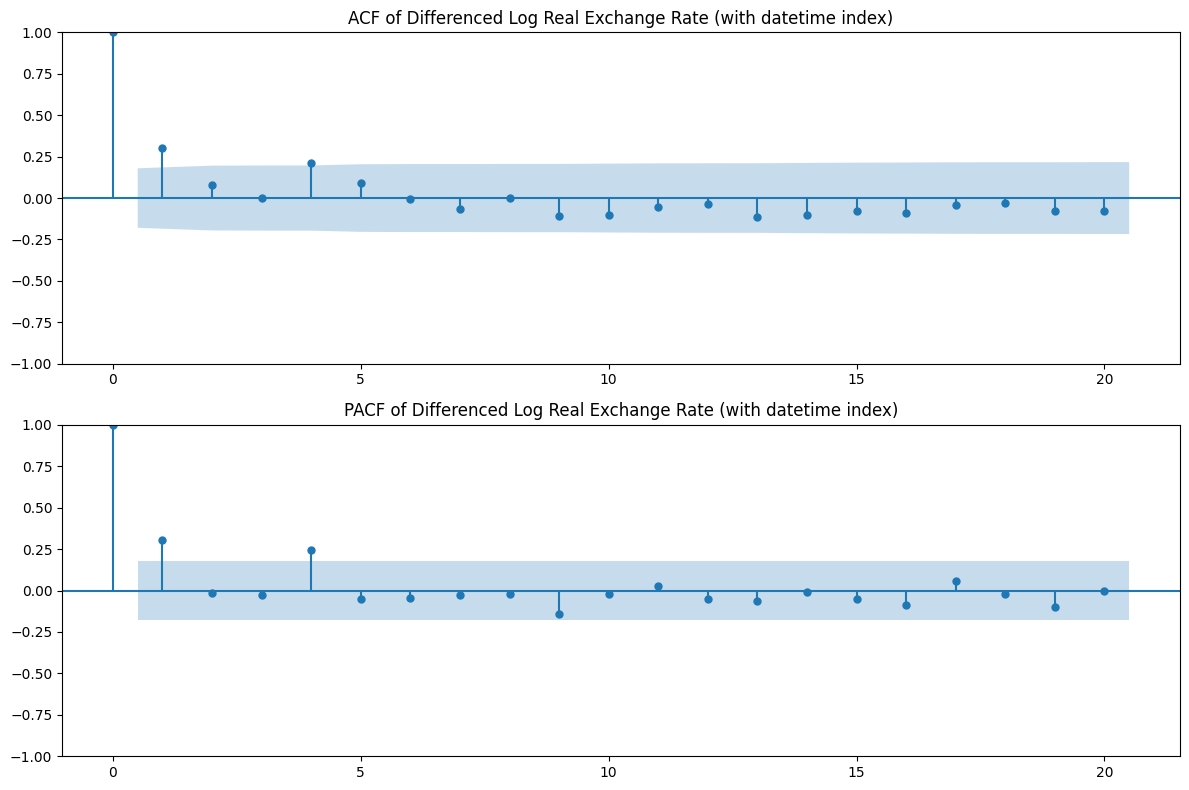

In [122]:
# Set DATE as index for better temporal alignment
combined_df.set_index('DATE', inplace=True)

# Recalculate differenced log real exchange rate with datetime index
combined_df['d_log_Real_Exchange_Rate'] = combined_df['log_Real_Exchange_Rate'].diff()
combined_diff_df = combined_df.dropna()

# Plot ACF and PACF again using datetime index
series = combined_diff_df['d_log_Real_Exchange_Rate']
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(series, lags=20, ax=axes[0])
axes[0].set_title('ACF of Differenced Log Real Exchange Rate (with datetime index)')

plot_pacf(series, lags=20, ax=axes[1])
axes[1].set_title('PACF of Differenced Log Real Exchange Rate (with datetime index)')

plt.tight_layout()
plt.show()


### Estimating 6 models for differenced log real exchange rate

In [124]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

# Prepare the series for ARIMA modeling: use the stationary version (first difference)
rer_series = combined_diff_df['d_log_Real_Exchange_Rate']

model_results = []

# Define ARIMA models to estimate
arima_orders = [(1, 0, 1), (2, 0, 1), (1, 0, 2), (2, 0, 2), (3, 0, 1), (3, 0, 2)]

for order in arima_orders:
    model = ARIMA(rer_series, order=order).fit()

    # Residual diagnostics
    residuals = model.resid
    t_stat, t_pval = stats.ttest_1samp(residuals, 0)
    lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
    q_pvalue = lb_test['lb_pvalue'].iloc[0]

    # Append results
    model_results.append({
        'Model': f'ARIMA{order}',
        'AIC': model.aic,
        'T-test p-value': t_pval,
        'Q-test p-value': q_pvalue,
        'Too Big (T p > 0.05)': t_pval > 0.05,
        'Too Small (Q p < 0.05)': q_pvalue < 0.05
    })

# Create results DataFrame
arima_results_df = pd.DataFrame(model_results)

# Display all 6 results
print(arima_results_df)

            Model         AIC  T-test p-value  Q-test p-value  \
0  ARIMA(1, 0, 1) -630.348715        0.991736        0.351727   
1  ARIMA(2, 0, 1) -628.334152        0.992072        0.351815   
2  ARIMA(1, 0, 2) -632.214016        0.996959        0.765401   
3  ARIMA(2, 0, 2) -631.151687        0.893619        0.765123   
4  ARIMA(3, 0, 1) -629.295347        0.968218        0.635004   
5  ARIMA(3, 0, 2) -628.472343        0.998748        0.738926   

   Too Big (T p > 0.05)  Too Small (Q p < 0.05)  
0                  True                   False  
1                  True                   False  
2                  True                   False  
3                  True                   False  
4                  True                   False  
5                  True                   False  


### Depiction of observed and 12 months Forecast of the best two ARIMA models

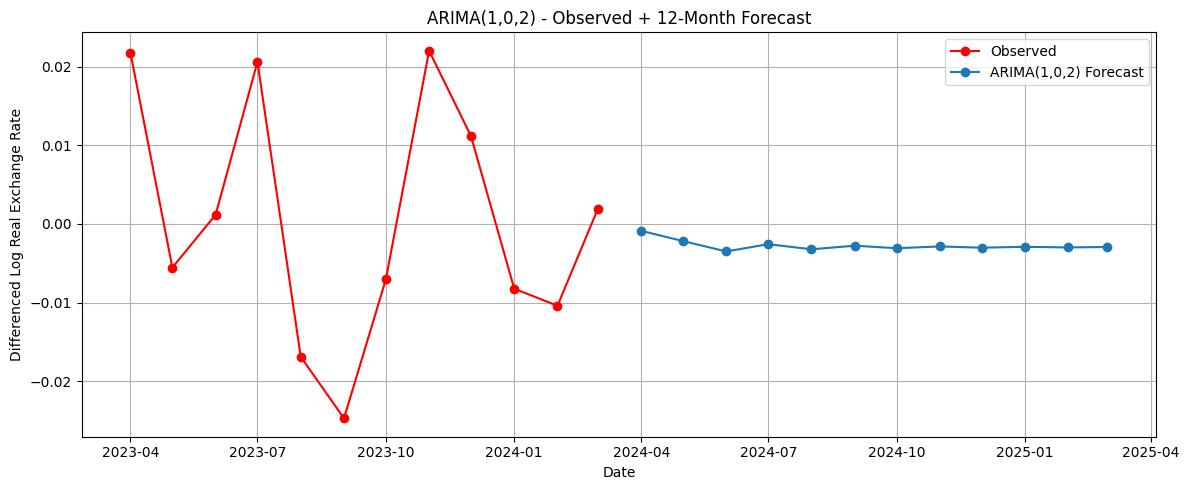

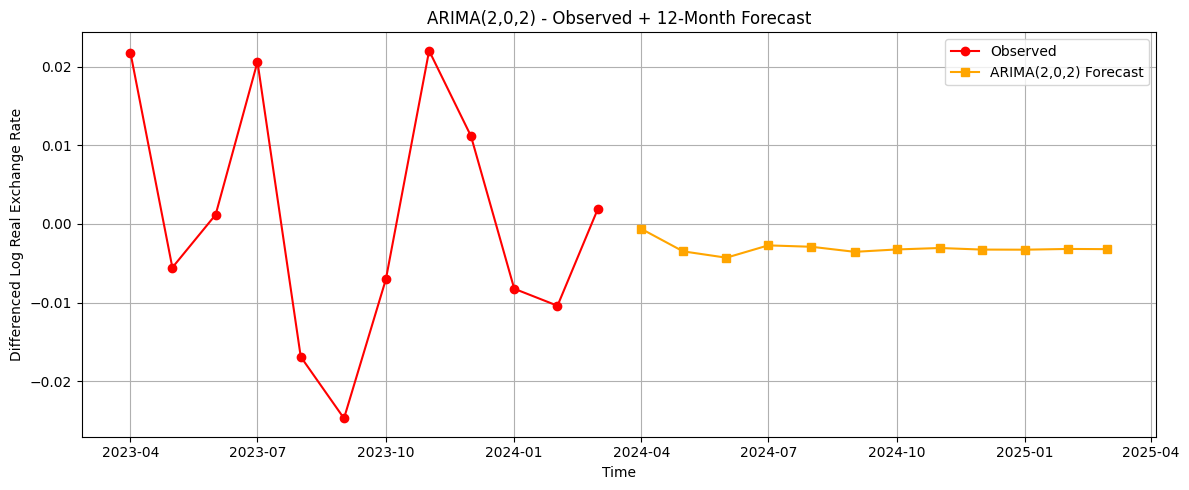

In [151]:
observed_recent = rer_series[-12:]
pd.date_range(start=observed_recent.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
# Combine last 12 observed values with forecasts for seamless plotting


combined_102 = pd.concat([observed_recent, f1_mean])
combined_202 = pd.concat([observed_recent, f2_mean])

# Generate a combined datetime index for the full 24 months (12 observed + 12 forecasted)
full_index = pd.date_range(start=observed_recent.index[0], periods=24, freq='MS')

# Reindex to ensure smooth plotting
combined_102.index = full_index
combined_202.index = full_index

# Plot ARIMA(1,0,2) combined
plt.figure(figsize=(12, 5))
plt.plot(combined_102.index[:12], combined_102[:12], label='Observed', marker='o', color='red')
plt.plot(combined_102.index[12:], combined_102[12:], label='ARIMA(1,0,2) Forecast', marker='o')
plt.title("ARIMA(1,0,2) - Observed + 12-Month Forecast")
plt.xlabel("Date")
plt.ylabel("Differenced Log Real Exchange Rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot ARIMA(2,0,2) combined
plt.figure(figsize=(12, 5))
plt.plot(combined_202.index[:12], combined_202[:12], label='Observed', marker='o', color='red')
plt.plot(combined_202.index[12:], combined_202[12:], label='ARIMA(2,0,2) Forecast', marker='s', color='orange')
plt.title("ARIMA(2,0,2) - Observed + 12-Month Forecast")
plt.xlabel("Time")
plt.ylabel("Differenced Log Real Exchange Rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### 12 Months forecast of the two best ARIMA Models

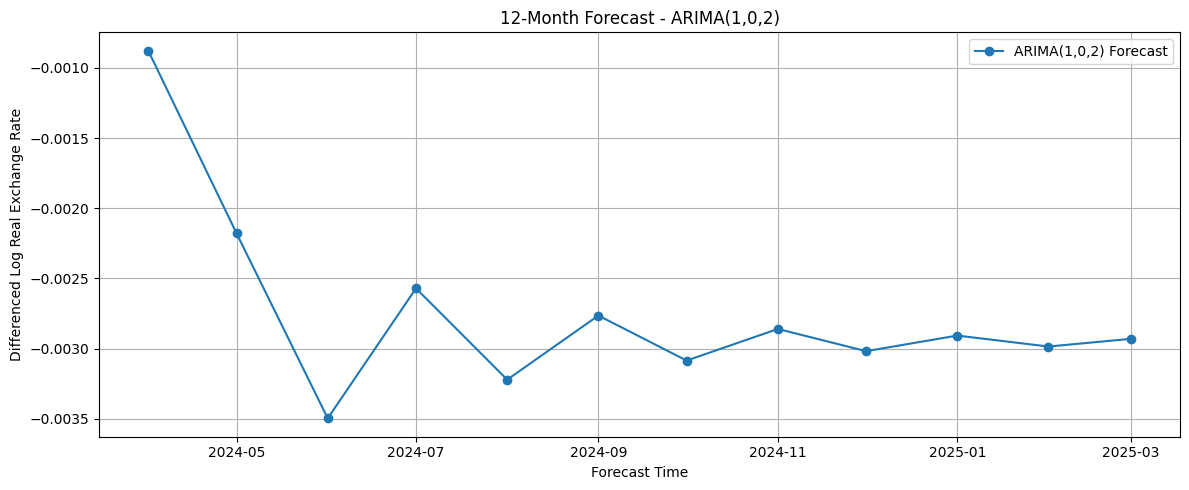

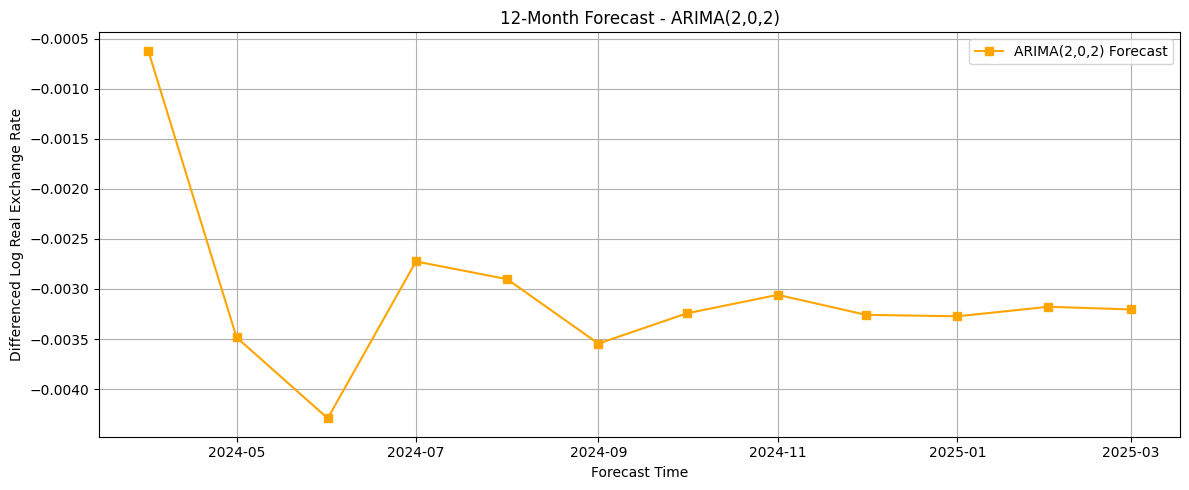

In [157]:
# Plotting ARIMA(1,0,2) forecast
plt.figure(figsize=(12, 5))
plt.plot(f1_mean.index, f1_mean, label='ARIMA(1,0,2) Forecast', marker='o')
plt.title("12-Month Forecast - ARIMA(1,0,2)")
plt.xlabel("Forecast Time")
plt.ylabel("Differenced Log Real Exchange Rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting ARIMA(2,0,2) forecast
plt.figure(figsize=(12, 5))
plt.plot(f2_mean.index, f2_mean, label='ARIMA(2,0,2) Forecast', marker='s', color='orange')
plt.title("12-Month Forecast - ARIMA(2,0,2)")
plt.xlabel("Forecast Time")
plt.ylabel("Differenced Log Real Exchange Rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### 12-month forecasts for the best two models and visualizing them on a combined graph with average forecast to show fluctuation

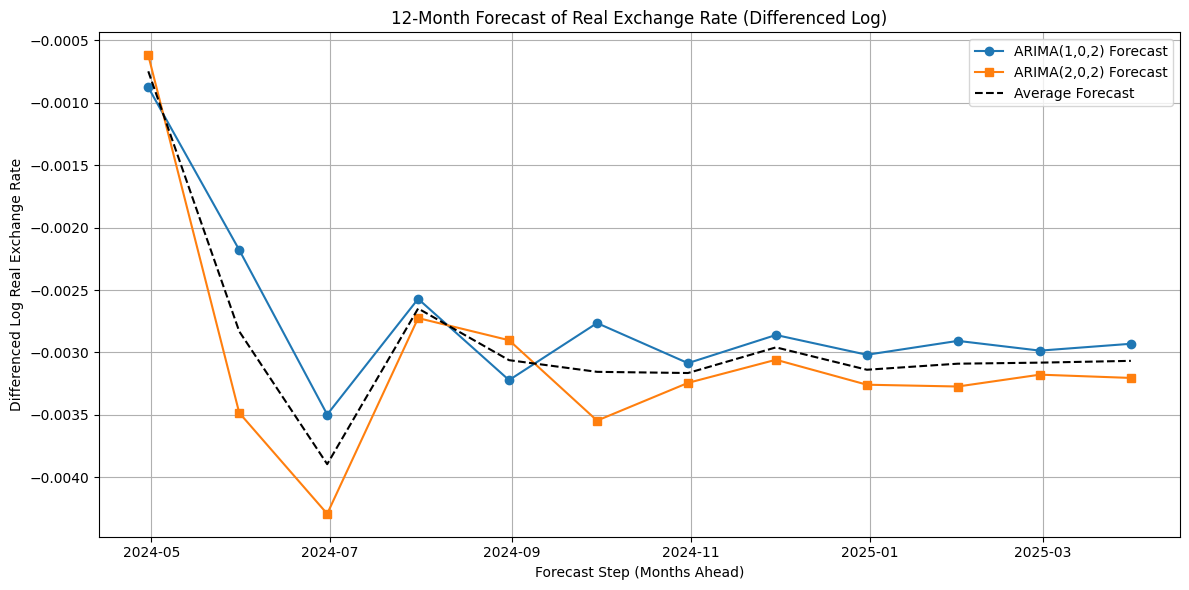

In [126]:
import matplotlib.pyplot as plt

# Fit the top two models again
model1 = ARIMA(rer_series, order=(1, 0, 2)).fit()
model2 = ARIMA(rer_series, order=(2, 0, 2)).fit()

# Generate 12-step forecasts
forecast_1 = model1.get_forecast(steps=12)
forecast_2 = model2.get_forecast(steps=12)

rer_series.index = pd.to_datetime(rer_series.index)
last_date = rer_series.index[-1]
forecast_start_date = last_date + pd.DateOffset(months=1)
forecast_index = pd.date_range(start=forecast_start_date, periods=12, freq='M').strftime('%b %Y')

# Set forecast_index as DatetimeIndex (not string)
forecast_index = pd.date_range(start=forecast_start_date, periods=12, freq='M')


# Forecast means
f1_mean = forecast_1.predicted_mean
f2_mean = forecast_2.predicted_mean

# Create plot
plt.figure(figsize=(12, 6))
plt.plot(forecast_index, f1_mean, label='ARIMA(1,0,2) Forecast', marker='o')
plt.plot(forecast_index, f2_mean, label='ARIMA(2,0,2) Forecast', marker='s')
plt.plot(forecast_index, (f1_mean + f2_mean) / 2, label='Average Forecast', linestyle='--', color='black')

plt.title("12-Month Forecast of Real Exchange Rate (Differenced Log)")
plt.xlabel("Forecast Step (Months Ahead)")
plt.ylabel("Differenced Log Real Exchange Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
